In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [24]:
df = pd.read_csv('/content/placement_predict_50k.csv')

df.head()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [25]:
df.shape

(50000, 31)

In [26]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values:
StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
dtype: int64

Missing values after cleaning:
StudentID             0
Gender                0
City                  0
CollegeTier           0
Stream

In [27]:
# Convert categorical columns into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 46)
Target shape: (50000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 46)
Testing data: (10000, 46)


In [29]:
# Create the decision tree
full_tree = DecisionTreeClassifier(random_state=42)

# Train the model
full_tree.fit(X_train, y_train)

# Make predictions
y_pred = full_tree.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Full Tree Accuracy:", accuracy)
print("Tree Depth:", full_tree.get_depth())

Full Tree Accuracy: 0.705
Tree Depth: 37


In [30]:
# Gini criterion
gini_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

gini_tree.fit(X_train, y_train)
gini_pred = gini_tree.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)


# Entropy criterion
entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

entropy_tree.fit(X_train, y_train)
entropy_pred = entropy_tree.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)


print("Gini Accuracy:", gini_accuracy)
print("Entropy Accuracy:", entropy_accuracy)

Gini Accuracy: 0.7946
Entropy Accuracy: 0.7954


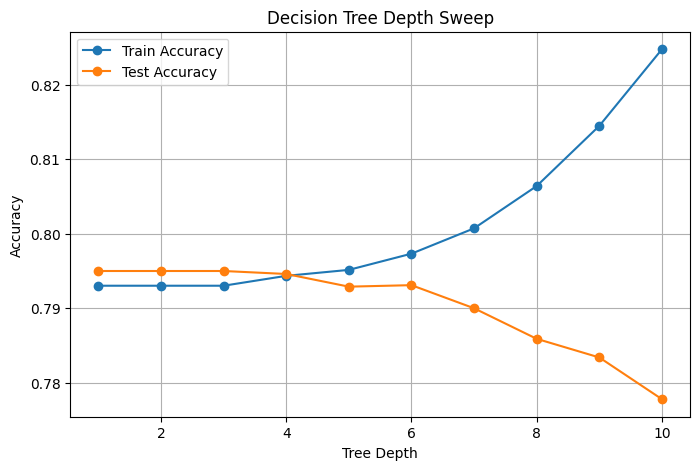

Best Depth: 1
Best Test Accuracy: 0.795


In [31]:
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(y_train, tree.predict(X_train))
    )

    test_scores.append(
        accuracy_score(y_test, tree.predict(X_test))
    )


plt.figure(figsize=(8, 5))

plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Sweep")
plt.legend()
plt.grid()
plt.show()


best_depth = depths[np.argmax(test_scores)]

print("Best Depth:", best_depth)
print("Best Test Accuracy:", max(test_scores))

In [32]:
# Find CCP pruning values
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

print("Number of alpha values:", len(ccp_alphas))
print("First few alpha values:", ccp_alphas[:10])

Number of alpha values: 2473
First few alpha values: [0.00000000e+00 1.24732334e-05 1.64215686e-05 1.65644172e-05
 1.65650407e-05 1.66067146e-05 1.66091954e-05 1.66380298e-05
 1.66469428e-05 1.66537367e-05]
